In [492]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
tickers = [
    "MMM",
    "AOS",
    "ABT",
    "ABBV",
    "ACN",
    "ADBE",
    "AMD",
    "AES",
    "AFL",
    "A",
    "APD",
    "ABNB",
    "AKAM",
    "ALB",
    "ARE",
    "ALGN",
    "ALLE",
    "LNT",
    "ALL",
    "GOOGL",
    "GOOG",
    "MO",
    "AMZN",
    "AMCR",
    "AEE",
    "AEP",
    "AXP",
    "AIG",
    "AMT",
    "AWK",
    "AMP",
    "AME",
    "AMGN",
    "APH",
    "ADI",
    "AON",
    "APA",
    "APO",
    "AAPL",
    "AMAT",
    "APP",
    "APTV",
    "ACGL",
    "ADM",
    "ARES",
    "ANET",
    "AJG",
    "AIZ",
    "T",
    "ATO",
    "ADSK",
    "ADP",
    "AZO",
    "AVB",
    "AVY",
    "AXON",
    "BKR",
    "BALL",
    "BAC",
    "BAX",
    "BDX",
    "BRK",
    "BBY",
    "TECH",
    "BIIB",
    "BLK",
    "BX",
    "XYZ",
    "BK",
    "BA",
    "BKNG",
    "BSX",
    "BMY",
    "AVGO",
    "BR",
    "BRO",
    "BF",
    "BLDR",
    "BG",
    "BXP",
    "CHRW",
    "CDNS",
    "CPT",
    "CPB",
    "COF",
    "CAH",
    "CCL",
    "CARR",
    "CVNA",
    "CASY",
    "CAT",
    "CBOE",
    "CBRE",
    "CDW",
    "COR",
    "CNC",
    "CNP",
    "CF",
    "CRL",
    "SCHW",
    "CHTR",
    "CVX",
    "CMG",
    "CB",
    "CHD",
    "CIEN",
    "CI",
    "CINF",
    "CTAS",
    "CSCO",
    "C",
    "CFG",
    "CLX",
    "CME",
    "CMS",
    "KO",
    "CTSH",
    "COHR",
    "COIN",
    "CL",
    "CMCSA",
    "FIX",
    "CAG",
    "COP",
    "ED",
    "STZ",
    "CEG",
    "COO",
    "CPRT",
    "GLW",
    "CPAY",
    "CTVA",
    "CSGP",
    "COST",
    "CTRA",
    "CRH",
    "CRWD",
    "CCI",
    "CSX",
    "CMI",
    "CVS",
    "DHR",
    "DRI",
    "DDOG",
    "DVA",
    "DECK",
    "DE",
    "DELL",
    "DAL",
    "DVN",
    "DXCM",
    "FANG",
    "DLR",
    "DG",
    "DLTR",
    "D",
    "DPZ",
    "DASH",
    "DOV",
    "DOW",
    "DHI",
    "DTE",
    "DUK",
    "DD",
    "ETN",
    "EBAY",
    "SATS",
    "ECL",
    "EIX",
    "EW",
    "EA",
    "ELV",
    "EME",
    "EMR",
    "ETR",
    "EOG",
    "EPAM",
    "EQT",
    "EFX",
    "EQIX",
    "EQR",
    "ERIE",
    "ESS",
    "EL",
    "EG",
    "EVRG",
    "ES",
    "EXC",
    "EXE",
    "EXPE",
    "EXPD",
    "EXR",
    "XOM",
    "FFIV",
    "FDS",
    "FICO",
    "FAST",
    "FRT",
    "FDX",
    "FIS",
    "FITB",
    "FSLR",
    "FE",
    "FISV",
    "F",
    "FTNT",
    "FTV",
    "FOXA",
    "FOX",
    "BEN",
    "FCX",
    "GRMN",
    "IT",
    "GE",
    "GEHC",
    "GEV",
    "GEN",
    "GNRC",
    "GD",
    "GIS",
    "GM",
    "GPC",
    "GILD",
    "GPN",
    "GL",
    "GDDY",
    "GS",
    "HAL",
    "HIG",
    "HAS",
    "HCA",
    "DOC",
    "HSIC",
    "HSY",
    "HPE",
    "HLT",
    "HD",
    "HON",
    "HRL",
    "HST",
    "HWM",
    "HPQ",
    "HUBB",
    "HUM",
    "HBAN",
    "HII",
    "IBM",
    "IEX",
    "IDXX",
    "ITW",
    "INCY",
    "IR",
    "PODD",
    "INTC",
    "IBKR",
    "ICE",
    "IFF",
    "IP",
    "INTU",
    "ISRG",
    "IVZ",
    "INVH",
    "IQV",
    "IRM",
    "JBHT",
    "JBL",
    "JKHY",
    "J",
    "JNJ",
    "JCI",
    "JPM",
    "KVUE",
    "KDP",
    "KEY",
    "KEYS",
    "KMB",
    "KIM",
    "KMI",
    "KKR",
    "KLAC",
    "KHC",
    "KR",
    "LHX",
    "LH",
    "LRCX",
    "LVS",
    "LDOS",
    "LEN",
    "LII",
    "LLY",
    "LIN",
    "LYV",
    "LMT",
    "L",
    "LOW",
    "LULU",
    "LITE",
    "LYB",
    "MTB",
    "MPC",
    "MAR",
    "MRSH",
    "MLM",
    "MAS",
    "MA",
    "MKC",
    "MCD",
    "MCK",
    "MDT",
    "MRK",
    "META",
    "MET",
    "MTD",
    "MGM",
    "MCHP",
    "MU",
    "MSFT",
    "MAA",
    "MRNA",
    "TAP",
    "MDLZ",
    "MPWR",
    "MNST",
    "MCO",
    "MS",
    "MOS",
    "MSI",
    "MSCI",
    "NDAQ",
    "NTAP",
    "NFLX",
    "NEM",
    "NWSA",
    "NWS",
    "NEE",
    "NKE",
    "NI",
    "NDSN",
    "NSC",
    "NTRS",
    "NOC",
    "NCLH",
    "NRG",
    "NUE",
    "NVDA",
    "NVR",
    "NXPI",
    "ORLY",
    "OXY",
    "ODFL",
    "OMC",
    "ON",
    "OKE",
    "ORCL",
    "OTIS",
    "PCAR",
    "PKG",
    "PLTR",
    "PANW",
    "PSKY",
    "PH",
    "PAYX",
    "PYPL",
    "PNR",
    "PEP",
    "PFE",
    "PCG",
    "PM",
    "PSX",
    "PNW",
    "PNC",
    "POOL",
    "PPG",
    "PPL",
    "PFG",
    "PG",
    "PGR",
    "PLD",
    "PRU",
    "PEG",
    "PTC",
    "PSA",
    "PHM",
    "PWR",
    "QCOM",
    "DGX",
    "Q",
    "RL",
    "RJF",
    "RTX",
    "O",
    "REG",
    "REGN",
    "RF",
    "RSG",
    "RMD",
    "RVTY",
    "HOOD",
    "ROK",
    "ROL",
    "ROP",
    "ROST",
    "RCL",
    "SPGI",
    "CRM",
    "SNDK",
    "SBAC",
    "SLB",
    "STX",
    "SRE",
    "NOW",
    "SHW",
    "SPG",
    "SWKS",
    "SJM",
    "SW",
    "SNA",
    "SOLV",
    "SO",
    "LUV",
    "SWK",
    "SBUX",
    "STT",
    "STLD",
    "STE",
    "SYK",
    "SMCI",
    "SYF",
    "SNPS",
    "SYY",
    "TMUS",
    "TROW",
    "TTWO",
    "TPR",
    "TRGP",
    "TGT",
    "TEL",
    "TDY",
    "TER",
    "TSLA",
    "TXN",
    "TPL",
    "TXT",
    "TMO",
    "TJX",
    "TKO",
    "TTD",
    "TSCO",
    "TT",
    "TDG",
    "TRV",
    "TRMB",
    "TFC",
    "TYL",
    "TSN",
    "USB",
    "UBER",
    "UDR",
    "ULTA",
    "UNP",
    "UAL",
    "UPS",
    "URI",
    "UNH",
    "UHS",
    "VLO",
    "VTR",
    "VLTO",
    "VRSN",
    "VRSK",
    "VZ",
    "VRTX",
    "VRT",
    "VTRS",
    "VICI",
    "V",
    "VST",
    "VMC",
    "WRB",
    "GWW",
    "WAB",
    "WMT",
    "DIS",
    "WBD",
    "WM",
    "WAT",
    "WEC",
    "WFC",
    "WELL",
    "WST",
    "WDC",
    "WY",
    "WSM",
    "WMB",
    "WTW",
    "WDAY",
    "WYNN",
    "XEL",
    "XYL",
    "YUM",
    "ZBRA",
    "ZBH",
    "ZTS",
]

In [552]:
data = yf.download(tickers, start="2015-01-01", end="2023-12-31")

[************          25%                       ]  126 of 503 completed$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
[****************      33%                       ]  165 of 503 completed$Q: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
[********************  42%                       ]  213 of 503 completed$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
[**********************61%****                   ]  306 of 503 completed$BF: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31)
[**********************68%********               ]  341 of 503 completed$BRK: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31)
[***

Text(0.02, 0.02, 'Sharpe: 0.65')

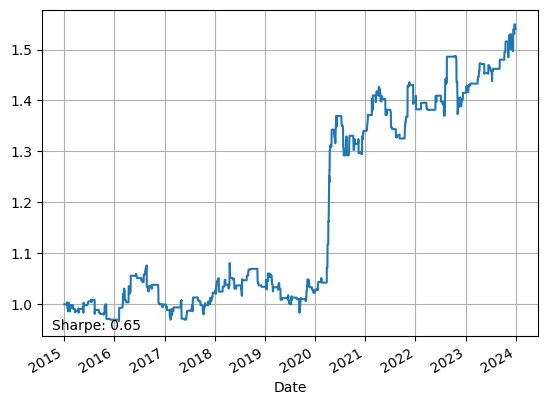

In [583]:
close_df = data["Close"].dropna(axis=1)
volume_df = data["Volume"].dropna(axis=1)
position_cnt = 25
asset_rank = 250
returns_df = close_df.pct_change().fillna(0)

# NOTE: signals
# signal_df = returns_df.rolling(120).mean()
base_signal = -returns_df.rolling(5).mean().shift(1)

# TEST: big moves
# move = returns_df.abs().rolling(5).mean()
# move_cutoff = move.quantile(0.1, axis=1)
# signal_df = base_signal.where(move.gt(move_cutoff, axis=0))

# TEST: volume spike filter
volm_win = 10
volm_z = (volume_df - volume_df.rolling(volm_win).mean()) / volume_df.rolling(volm_win).std()

# TEST: long term momentum filter
long_mom = returns_df.rolling(10).mean()

signal_df = base_signal.where(
    volm_z.gt(volm_z.quantile(0.85, axis=1), axis=0)
    & long_mom.abs().lt(long_mom.quantile(0.75, axis=1), axis=0)
)

dollar_vol_df = (close_df * volume_df).dropna(axis=1)
avg_dollar_vol_df = dollar_vol_df.rolling(60).mean()

rank_df = avg_dollar_vol_df.rank(axis=1, ascending=False, na_option="bottom")
rank_mask = rank_df <= asset_rank

filtered_returns = returns_df.where(rank_mask)
filtered_signal_df = signal_df.where(rank_mask)

signal_rank = filtered_signal_df.rank(axis=1, ascending=False)

long = signal_rank <= position_cnt
short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
short = signal_rank.ge(short_cutoff.values[:, None])

positions = long.astype(int) - short.astype(int)
positions = positions.div(positions.abs().sum(axis=1), axis=0)

pnl = positions.shift(1) * filtered_returns
port_ret = pnl.sum(axis=1)
sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)
cum_pnl = (1 + port_ret).cumprod()

ax = cum_pnl.plot(grid=True)

plt.text(0.02, 0.02, f"Sharpe: {sharpe:.2f}", transform=ax.transAxes)

<Axes: >

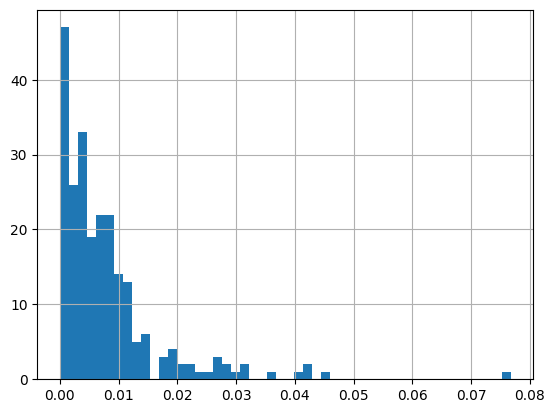

In [581]:
port_ret[port_ret > 0].hist(bins=50)

In [538]:
close_df = data["Close"].dropna(axis=1)
volume_df = data["Volume"].dropna(axis=1)
position_cnt = 25
returns_df = close_df.pct_change().fillna(0)
base_signal = -returns_df.rolling(5).mean().shift(1)
sr = []

for volm_wind in np.arange(10, 100, 10):
    for volm_qt in [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
        for mt_wind in np.arange(10, 100, 10):
            for mt_qt in [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
                # TEST: volume spike filter
                volm_z = (volume_df - volume_df.rolling(volm_wind).mean()) / volume_df.rolling(
                    volm_wind
                ).std()

                # TEST: long term momentum filter
                long_mom = returns_df.rolling(mt_wind).mean()

                signal_df = base_signal.where(
                    volm_z.gt(volm_z.quantile(volm_qt, axis=1), axis=0)
                    & long_mom.abs().lt(long_mom.quantile(mt_qt, axis=1), axis=0)
                )

                # NOTE: liquidity filt
                dollar_vol_df = (close_df * volume_df).dropna(axis=1)
                avg_dollar_vol_df = dollar_vol_df.rolling(60).mean()

                rank_df = avg_dollar_vol_df.rank(axis=1, ascending=False)
                rank_mask = rank_df <= asset_rank

                filtered_returns = returns_df.where(rank_mask)
                filtered_signal_df = signal_df.where(rank_mask)

                signal_rank = filtered_signal_df.rank(axis=1, ascending=False)

                long = signal_rank <= position_cnt
                short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
                short = signal_rank.ge(short_cutoff.values[:, None])

                positions = long.astype(int) - short.astype(int)
                positions = positions.div(positions.abs().sum(axis=1), axis=0)

                pnl = positions.shift(1) * filtered_returns
                port_ret = pnl.sum(axis=1)
                sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)

                print(
                    "volm_wind=",
                    volm_wind,
                    "/volm_qt=",
                    volm_qt,
                    "/mt_wind=",
                    mt_wind,
                    "/mt_qt=",
                    mt_qt,
                    "/sharpe=",
                    sharpe,
                )

                if sharpe >= 1.0:
                    sr.append([volm_wind, volm_qt, mt_wind, mt_qt, sharpe])

volm_wind= 10 /volm_qt= 0.6 /mt_wind= 10 /mt_qt= 0.6 /sharpe= 0.06996426627017452
volm_wind= 10 /volm_qt= 0.6 /mt_wind= 10 /mt_qt= 0.65 /sharpe= 1.1318608704169277
volm_wind= 10 /volm_qt= 0.6 /mt_wind= 10 /mt_qt= 0.7 /sharpe= 0.7585187187636567
volm_wind= 10 /volm_qt= 0.6 /mt_wind= 10 /mt_qt= 0.75 /sharpe= 1.0065281495153142
volm_wind= 10 /volm_qt= 0.6 /mt_wind= 10 /mt_qt= 0.8 /sharpe= 1.4998737669542934
volm_wind= 10 /volm_qt= 0.6 /mt_wind= 10 /mt_qt= 0.85 /sharpe= 1.2002046552922758
volm_wind= 10 /volm_qt= 0.6 /mt_wind= 10 /mt_qt= 0.9 /sharpe= 0.6619071909814139
volm_wind= 10 /volm_qt= 0.6 /mt_wind= 20 /mt_qt= 0.6 /sharpe= 0.8913016658022077
volm_wind= 10 /volm_qt= 0.6 /mt_wind= 20 /mt_qt= 0.65 /sharpe= 0.6002710672621927
volm_wind= 10 /volm_qt= 0.6 /mt_wind= 20 /mt_qt= 0.7 /sharpe= 0.49866592511182123
volm_wind= 10 /volm_qt= 0.6 /mt_wind= 20 /mt_qt= 0.75 /sharpe= 0.43075562343479795
volm_wind= 10 /volm_qt= 0.6 /mt_wind= 20 /mt_qt= 0.8 /sharpe= 0.29748446417568264
volm_wind= 10 /volm

/var/folders/8_/wzdkmfn13sd6lvk4c6xz3cph0000gp/T/ipykernel_27573/2079478334.py:43: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)
/var/folders/8_/wzdkmfn13sd6lvk4c6xz3cph0000gp/T/ipykernel_27573/2079478334.py:43: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)


volm_wind= 10 /volm_qt= 0.9 /mt_wind= 10 /mt_qt= 0.6 /sharpe= nan
volm_wind= 10 /volm_qt= 0.9 /mt_wind= 10 /mt_qt= 0.65 /sharpe= nan


/var/folders/8_/wzdkmfn13sd6lvk4c6xz3cph0000gp/T/ipykernel_27573/2079478334.py:43: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)
/var/folders/8_/wzdkmfn13sd6lvk4c6xz3cph0000gp/T/ipykernel_27573/2079478334.py:43: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)


volm_wind= 10 /volm_qt= 0.9 /mt_wind= 10 /mt_qt= 0.7 /sharpe= nan
volm_wind= 10 /volm_qt= 0.9 /mt_wind= 10 /mt_qt= 0.75 /sharpe= nan


...

volm_wind= 90 /volm_qt= 0.9 /mt_wind= 90 /mt_qt= 0.65 /sharpe= nan


/var/folders/8_/wzdkmfn13sd6lvk4c6xz3cph0000gp/T/ipykernel_27573/2079478334.py:43: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)


volm_wind= 90 /volm_qt= 0.9 /mt_wind= 90 /mt_qt= 0.7 /sharpe= nan


/var/folders/8_/wzdkmfn13sd6lvk4c6xz3cph0000gp/T/ipykernel_27573/2079478334.py:43: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)


volm_wind= 90 /volm_qt= 0.9 /mt_wind= 90 /mt_qt= 0.75 /sharpe= nan
volm_wind= 90 /volm_qt= 0.9 /mt_wind= 90 /mt_qt= 0.8 /sharpe= 0.5004967711111074
volm_wind= 90 /volm_qt= 0.9 /mt_wind= 90 /mt_qt= 0.85 /sharpe= -0.05807584173500819
volm_wind= 90 /volm_qt= 0.9 /mt_wind= 90 /mt_qt= 0.9 /sharpe= 0.24702361981188287


In [541]:
sr_df = pd.DataFrame(sr, columns=["volm_wind", "volm_qt", "mt_wind", "mt_qt", "sharpe"])
sr_df.shape

(110, 5)

In [551]:
sr_df.sort_values(by="sharpe", ascending=False).head(20)

,volm_wind,volm_qt,mt_wind,mt_qt,sharpe
34,20,0.75,20,0.60,1.564196
76,60,0.75,20,0.65,1.542007
2,10,0.60,10,0.80,1.499874
21,10,0.80,10,0.80,1.473407
65,50,0.75,20,0.65,1.459988
30,20,0.70,30,0.60,1.451383
69,60,0.65,10,0.85,1.438380
53,40,0.75,20,0.65,1.412422
58,50,0.65,10,0.85,1.391978
62,50,0.70,30,0.70,1.385873


## Momentum

In [578]:
sr = {}
close_df = data["Close"].dropna(axis=1)
volume_df = data["Volume"].dropna(axis=1)
position_cnt = 25
returns_df = close_df.pct_change().fillna(0)
base_signal = -returns_df.rolling(5).mean().shift(1)

for wind in np.arange(5, 100, 5):
    for qt in [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
        print("window=", wind, " / qt=", qt)
        # vol_z = (volume_df - volume_df.rolling(vol_win).mean()) / volume_df.rolling(vol_win).std()
        # signal_df = base_signal.where(vol_z.gt(vol_z.quantile(qt, axis=1), axis=0))

        # realized_vol = returns_df.rolling(10).std()
        # vol_z = (realized_vol - realized_vol.rolling(wind).mean()) / realized_vol.rolling(wind).std()
        # signal_df = base_signal.where(vol_z.gt(vol_z.quantile(qt, axis=1), axis=0))

        long_mom = returns_df.rolling(wind).mean()
        mom_cutoff = long_mom.abs().quantile(qt, axis=1)
        signal_df = base_signal.where(long_mom.abs().lt(mom_cutoff, axis=0))

        dollar_vol_df = (close_df * volume_df).dropna(axis=1)
        avg_dollar_vol_df = dollar_vol_df.rolling(60).mean()

        rank_df = avg_dollar_vol_df.rank(axis=1, ascending=False)
        rank_mask = rank_df <= asset_rank

        filtered_returns = returns_df.where(rank_mask)
        filtered_signal_df = signal_df.where(rank_mask)

        signal_rank = filtered_signal_df.rank(axis=1, ascending=False)

        long = signal_rank <= position_cnt
        short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
        short = signal_rank.ge(short_cutoff.values[:, None])

        positions = long.astype(int) - short.astype(int)
        positions = positions.div(positions.abs().sum(axis=1), axis=0)

        pnl = positions.shift(1) * filtered_returns
        port_ret = pnl.sum(axis=1)
        sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)

        qt_key = f"{qt}"
        if qt_key not in sr:
            sr[qt_key] = {}

        sr[qt_key][f"{wind}"] = sharpe

# plt.figure()
# plt.plot(sr.keys(), sr.values())
# plt.xlabel('vol window')
# plt.ylabel('sharpe')
# plt.show()

window= 5  / qt= 0.6
window= 5  / qt= 0.65
window= 5  / qt= 0.7
window= 5  / qt= 0.75
window= 5  / qt= 0.8
window= 5  / qt= 0.85
window= 5  / qt= 0.9
window= 10  / qt= 0.6
window= 10  / qt= 0.65
window= 10  / qt= 0.7
window= 10  / qt= 0.75
window= 10  / qt= 0.8
window= 10  / qt= 0.85
window= 10  / qt= 0.9
window= 15  / qt= 0.6
window= 15  / qt= 0.65
window= 15  / qt= 0.7
window= 15  / qt= 0.75
window= 15  / qt= 0.8
window= 15  / qt= 0.85
window= 15  / qt= 0.9
window= 20  / qt= 0.6
window= 20  / qt= 0.65
window= 20  / qt= 0.7
window= 20  / qt= 0.75
window= 20  / qt= 0.8
window= 20  / qt= 0.85
window= 20  / qt= 0.9
window= 25  / qt= 0.6
window= 25  / qt= 0.65
window= 25  / qt= 0.7
window= 25  / qt= 0.75
window= 25  / qt= 0.8
window= 25  / qt= 0.85
window= 25  / qt= 0.9
window= 30  / qt= 0.6
window= 30  / qt= 0.65
window= 30  / qt= 0.7
window= 30  / qt= 0.75
window= 30  / qt= 0.8
window= 30  / qt= 0.85
window= 30  / qt= 0.9
window= 35  / qt= 0.6
window= 35  / qt= 0.65
window= 35  / qt= 0.

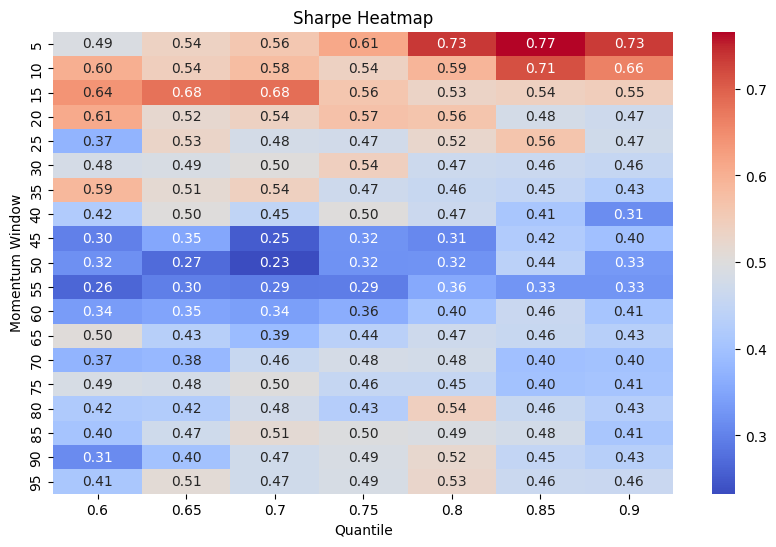

In [579]:
hm_df = pd.DataFrame(sr).astype(float)
hm_df.index = hm_df.index.astype(int)  # vol window
hm_df.columns = hm_df.columns.astype(float)  # quantiles

plt.figure(figsize=(10, 6))
sns.heatmap(hm_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.xlabel("Quantile")
plt.ylabel("Momentum Window")
plt.title("Sharpe Heatmap")
plt.show()

## Volatility Study

window= 15  / qt= 0.6
window= 15  / qt= 0.65
window= 15  / qt= 0.7
window= 15  / qt= 0.75
window= 15  / qt= 0.8
window= 15  / qt= 0.85
window= 15  / qt= 0.9
window= 20  / qt= 0.6
window= 20  / qt= 0.65
window= 20  / qt= 0.7
window= 20  / qt= 0.75
window= 20  / qt= 0.8
window= 20  / qt= 0.85
window= 20  / qt= 0.9
window= 25  / qt= 0.6
window= 25  / qt= 0.65
window= 25  / qt= 0.7
window= 25  / qt= 0.75
window= 25  / qt= 0.8
window= 25  / qt= 0.85
window= 25  / qt= 0.9
window= 30  / qt= 0.6
window= 30  / qt= 0.65
window= 30  / qt= 0.7
window= 30  / qt= 0.75
window= 30  / qt= 0.8
window= 30  / qt= 0.85
window= 30  / qt= 0.9
window= 35  / qt= 0.6
window= 35  / qt= 0.65
window= 35  / qt= 0.7
window= 35  / qt= 0.75
window= 35  / qt= 0.8
window= 35  / qt= 0.85
window= 35  / qt= 0.9
window= 40  / qt= 0.6
window= 40  / qt= 0.65
window= 40  / qt= 0.7
window= 40  / qt= 0.75
window= 40  / qt= 0.8
window= 40  / qt= 0.85
window= 40  / qt= 0.9
window= 45  / qt= 0.6
window= 45  / qt= 0.65
window= 45  /

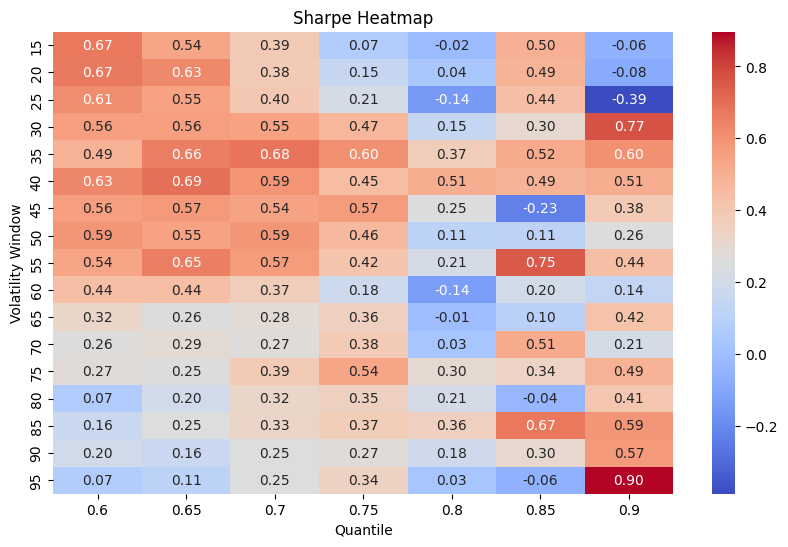

In [518]:
sr = {}
close_df = data["Close"].dropna(axis=1)
volume_df = data["Volume"].dropna(axis=1)
position_cnt = 25
returns_df = close_df.pct_change().fillna(0)
base_signal = -returns_df.rolling(5).mean().shift(1)

for wind in np.arange(15, 100, 5):
    for qt in [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
        print("window=", wind, " / qt=", qt)
        # vol_z = (volume_df - volume_df.rolling(vol_win).mean()) / volume_df.rolling(vol_win).std()
        # signal_df = base_signal.where(vol_z.gt(vol_z.quantile(qt, axis=1), axis=0))

        realized_vol = returns_df.rolling(10).std()
        vol_z = (realized_vol - realized_vol.rolling(wind).mean()) / realized_vol.rolling(
            wind
        ).std()
        signal_df = base_signal.where(vol_z.gt(vol_z.quantile(qt, axis=1), axis=0))

        # vol_cutoff = realized_vol.quantile(qt, axis=1)
        # signal_df = base_signal.where(realized_vol.gt(vol_cutoff, axis=0))

        dollar_vol_df = (close_df * volume_df).dropna(axis=1)
        avg_dollar_vol_df = dollar_vol_df.rolling(60).mean()

        rank_df = avg_dollar_vol_df.rank(axis=1, ascending=False)
        rank_mask = rank_df <= 200

        filtered_returns = returns_df.where(rank_mask)
        filtered_signal_df = signal_df.where(rank_mask)

        signal_rank = filtered_signal_df.rank(axis=1, ascending=False)

        long = signal_rank <= position_cnt
        short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
        short = signal_rank.ge(short_cutoff.values[:, None])

        positions = long.astype(int) - short.astype(int)
        positions = positions.div(positions.abs().sum(axis=1), axis=0)

        pnl = positions.shift(1) * filtered_returns
        port_ret = pnl.sum(axis=1)
        sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)

        qt_key = f"{qt}"
        if qt_key not in sr:
            sr[qt_key] = {}

        sr[qt_key][f"{wind}"] = sharpe

# plt.figure()
# plt.plot(sr.keys(), sr.values())
# plt.xlabel('vol window')
# plt.ylabel('sharpe')
# plt.show()

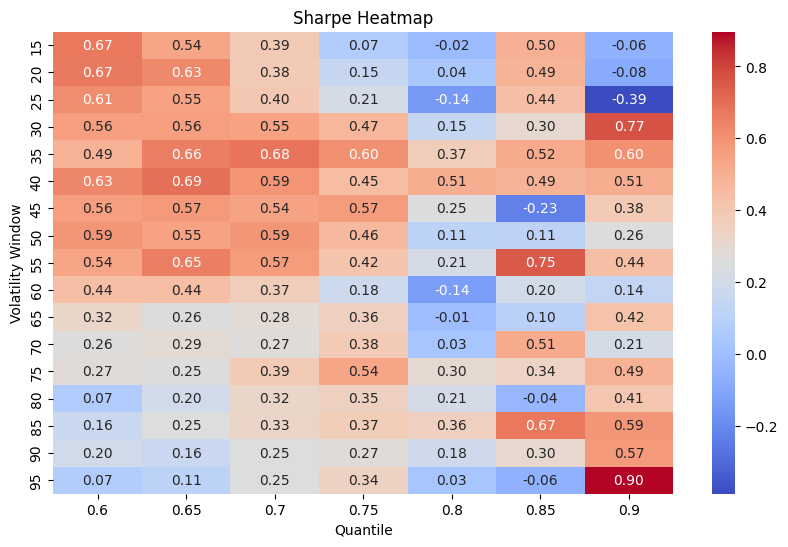

In [520]:
hm_df = pd.DataFrame(sr).astype(float)
hm_df.index = hm_df.index.astype(int)  # vol window
hm_df.columns = hm_df.columns.astype(float)  # quantiles

plt.figure(figsize=(10, 6))
sns.heatmap(hm_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.xlabel("Quantile")
plt.ylabel("Volatility Window")
plt.title("Sharpe Heatmap")
plt.show()

In [517]:
sr

{'0.6': {'95': np.float64(0.0716432894185627)},
 '0.65': {'95': np.float64(0.10943073398135866)},
 '0.7': {'95': np.float64(0.2491825662768464)},
 '0.75': {'95': np.float64(0.33918849048302585)},
 '0.8': {'95': np.float64(0.02936850277247941)},
 '0.85': {'95': np.float64(-0.0592680625117774)},
 '0.9': {'95': np.float64(0.8964956354760263)}}

## Volume Studies

In [556]:
sr = {}
close_df = data["Close"].dropna(axis=1)
volume_df = data["Volume"].dropna(axis=1)
position_cnt = 25
returns_df = close_df.pct_change().fillna(0)
base_signal = -returns_df.rolling(5).mean().shift(1)

for vol_win in np.arange(5, 100, 5):
    for qt in [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
        print("vol_win=", vol_win, " / qt=", qt)
        # TEST: volume spike filter
        vol_z = (volume_df - volume_df.rolling(vol_win).mean()) / volume_df.rolling(vol_win).std()
        signal_df = base_signal.where(vol_z.gt(vol_z.quantile(qt, axis=1), axis=0))

        dollar_vol_df = (close_df * volume_df).dropna(axis=1)
        avg_dollar_vol_df = dollar_vol_df.rolling(60).mean()

        rank_df = avg_dollar_vol_df.rank(axis=1, ascending=False)
        rank_mask = rank_df <= 200

        filtered_returns = returns_df.where(rank_mask)
        filtered_signal_df = signal_df.where(rank_mask)

        signal_rank = filtered_signal_df.rank(axis=1, ascending=False)

        long = signal_rank <= position_cnt
        short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
        short = signal_rank.ge(short_cutoff.values[:, None])

        positions = long.astype(int) - short.astype(int)
        positions = positions.div(positions.abs().sum(axis=1), axis=0)

        pnl = positions.shift(1) * filtered_returns
        port_ret = pnl.sum(axis=1)
        sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)

        qt_key = f"{qt}"
        if qt_key not in sr:
            sr[qt_key] = {}

        sr[qt_key][f"{vol_win}"] = sharpe

# plt.figure()
# plt.plot(sr.keys(), sr.values())
# plt.xlabel('vol window')
# plt.ylabel('sharpe')
# plt.show()

vol_win= 5  / qt= 0.6
vol_win= 5  / qt= 0.65
vol_win= 5  / qt= 0.7
vol_win= 5  / qt= 0.75
vol_win= 5  / qt= 0.8
vol_win= 5  / qt= 0.85
vol_win= 5  / qt= 0.9
vol_win= 10  / qt= 0.6
vol_win= 10  / qt= 0.65
vol_win= 10  / qt= 0.7
vol_win= 10  / qt= 0.75
vol_win= 10  / qt= 0.8
vol_win= 10  / qt= 0.85
vol_win= 10  / qt= 0.9
vol_win= 15  / qt= 0.6
vol_win= 15  / qt= 0.65
vol_win= 15  / qt= 0.7
vol_win= 15  / qt= 0.75
vol_win= 15  / qt= 0.8
vol_win= 15  / qt= 0.85
vol_win= 15  / qt= 0.9
vol_win= 20  / qt= 0.6
vol_win= 20  / qt= 0.65
vol_win= 20  / qt= 0.7
vol_win= 20  / qt= 0.75
vol_win= 20  / qt= 0.8
vol_win= 20  / qt= 0.85
vol_win= 20  / qt= 0.9
vol_win= 25  / qt= 0.6
vol_win= 25  / qt= 0.65
vol_win= 25  / qt= 0.7
vol_win= 25  / qt= 0.75
vol_win= 25  / qt= 0.8
vol_win= 25  / qt= 0.85
vol_win= 25  / qt= 0.9
vol_win= 30  / qt= 0.6
vol_win= 30  / qt= 0.65
vol_win= 30  / qt= 0.7
vol_win= 30  / qt= 0.75
vol_win= 30  / qt= 0.8
vol_win= 30  / qt= 0.85
vol_win= 30  / qt= 0.9
vol_win= 35  / qt= 0.6


In [557]:
hm_df = pd.DataFrame(sr).astype(float)
hm_df.index = hm_df.index.astype(int)  # vol window
hm_df.columns = hm_df.columns.astype(float)  # quantiles

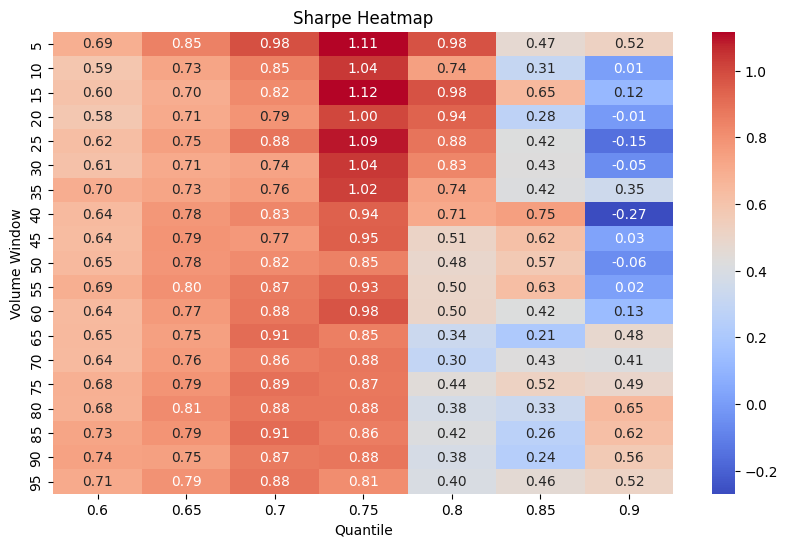

In [558]:
plt.figure(figsize=(10, 6))
sns.heatmap(hm_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.xlabel("Quantile")
plt.ylabel("Volume Window")

plt.title("Sharpe Heatmap")

plt.show()

## Misc

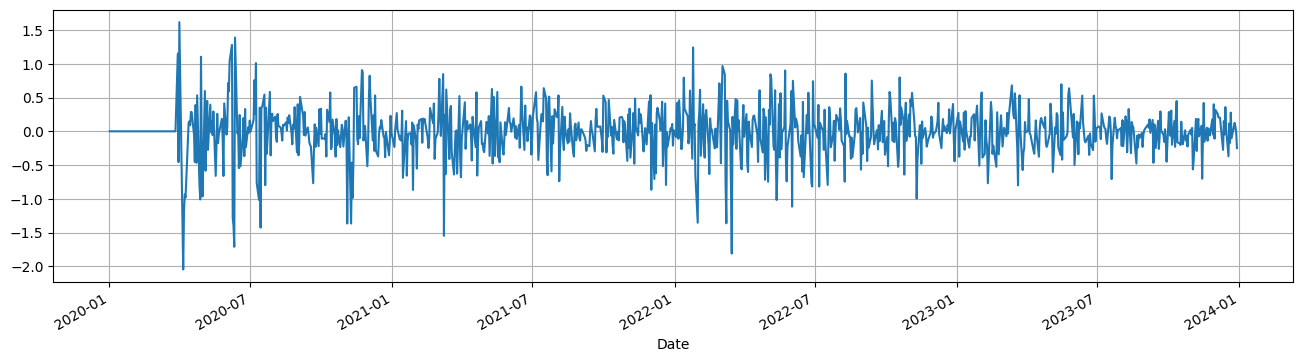

In [356]:
ax = pnl.sum(axis=1).plot(figsize=(16, 4), grid=True)

In [343]:
pnl.to_csv("pnl.csv", header=True)

In [234]:
print(close_df.shape, volume_df.shape)
print(close_df.columns.equals(volume_df.columns))
print(close_df.index.equals(volume_df.index))

(1006, 484) (1006, 484)
True
True


In [244]:
print(rank_df.index[0])
print(rank_mask.index[0])
print(filtered_returns.index[0])

2020-03-27 00:00:00
2020-03-27 00:00:00
2020-01-02 00:00:00


In [56]:
# ----------------------------
# 1. Download data
# ----------------------------
tickers = {"TSLA": "TSLA", "SPY": "SPY", "XLK": "XLK", "IWF": "IWF", "IWD": "IWD"}

data = yf.download(list(tickers.values()), start="2020-01-01")["Close"]

volume = yf.download("TSLA", start="2020-01-01")["Volume"]

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

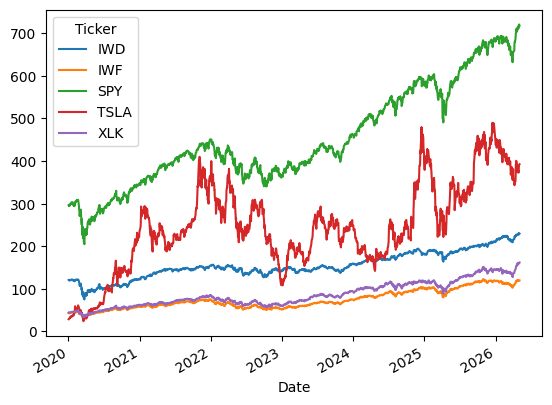

In [57]:
data.plot()

In [64]:
# ----------------------------
# 2. Compute returns
# ----------------------------
returns = data.pct_change().dropna()

# Rename for clarity
returns.columns = ["TSLA", "MKT", "SECTOR", "IWF", "IWD"]

liq = (returns["TSLA"].abs() / volume["TSLA"]).rolling(20).mean()

In [115]:
# ----------------------------
# 3. Run regression
# TSLA ~ Market + Sector + QQQ
# ----------------------------
# Y = returns["TSLA"]
# X = returns[["MKT", "SECTOR"]]
# X = sm.add_constant(X)
# Momentum (past 20-day return)
mom = returns["TSLA"].rolling(20).mean()

# Volatility (20-day rolling std)
vol = returns["TSLA"].rolling(20).std()

df = pd.DataFrame(
    {
        "TSLA": returns["TSLA"],
        "MKT": returns["MKT"],
        "SECTOR": returns["SECTOR"],
        "IWF": returns["IWF"],
        "IWD": returns["IWD"],
        "MOM": mom,
        "VOL": vol,
        "VOLUME": volume["TSLA"],
        "LIQ": liq,
    }
).dropna()

Y = df["TSLA"]
# X = df[["MKT", , "MOM", "VOL", "IWF", "IWD", "VOLUME", "LIQ"]]
X = df[["MKT", "MOM", "VOL"]]
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
residuals = model.resid

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   TSLA   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     867.3
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        19:05:22   Log-Likelihood:                 5420.3
No. Observations:                1572   AIC:                        -1.083e+04
Df Residuals:                    1568   BIC:                        -1.081e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0008      0.000     -2.295      0.0

In [116]:
df[["MKT", "SECTOR", "MOM", "VOL", "IWF", "IWD", "VOLUME", "LIQ"]].corr()

,MKT,SECTOR,MOM,VOL,IWF,IWD,VOLUME,LIQ
MKT,1.000000,0.958653,0.154475,0.042897,0.598431,0.973312,0.008145,0.005186
SECTOR,0.958653,1.000000,0.188606,0.037668,0.534798,0.931347,-0.011329,0.019461
MOM,0.154475,0.188606,1.000000,-0.364601,0.104096,0.135251,-0.128925,-0.237865
VOL,0.042897,0.037668,-0.364601,1.000000,0.035588,0.042961,0.387035,0.552051
IWF,0.598431,0.534798,0.104096,0.035588,1.000000,0.549007,0.119897,-0.010245
IWD,0.973312,0.931347,0.135251,0.042961,0.549007,1.000000,0.004763,0.010721
VOLUME,0.008145,-0.011329,-0.128925,0.387035,0.119897,0.004763,1.000000,-0.199873
LIQ,0.005186,0.019461,-0.237865,0.552051,-0.010245,0.010721,-0.199873,1.000000


In [117]:
# ----------------------------
# 4. Extract residuals
# ----------------------------
residuals = model.resid

<Axes: xlabel='Date'>

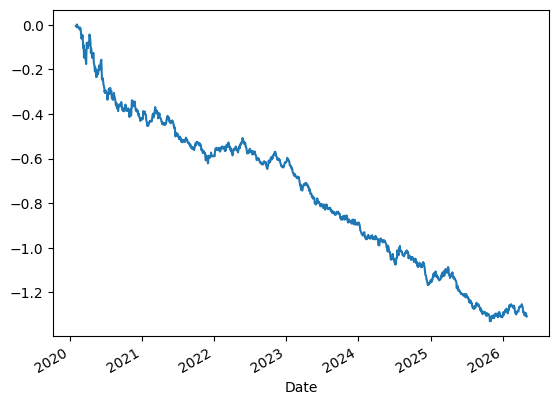

In [118]:
alpha_contr = model.params["const"] + model.resid
alpha_contr.cumsum().plot()

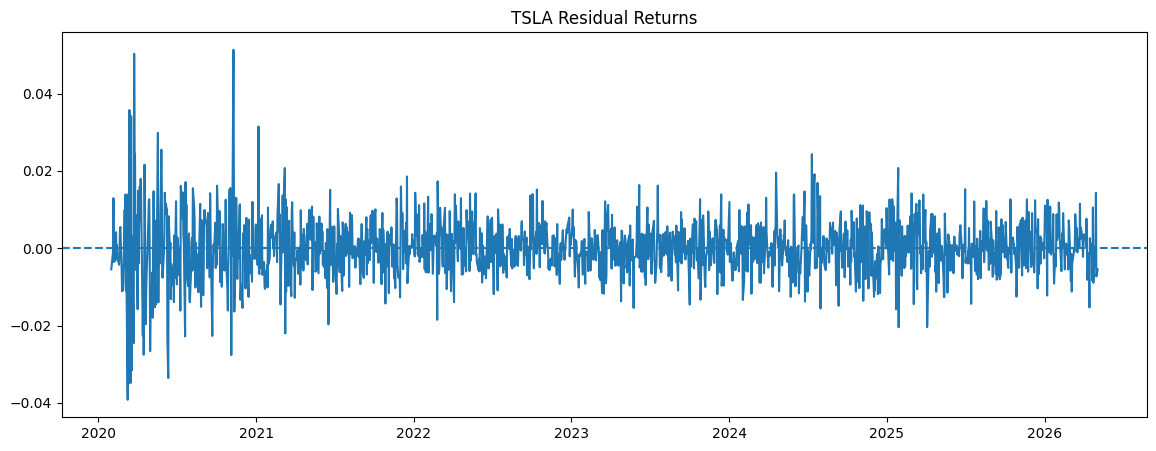

In [119]:
# ----------------------------
# 5. Plot residuals
# ----------------------------
plt.figure(figsize=(14, 5))
plt.plot(residuals)
plt.title("TSLA Residual Returns")
plt.axhline(0, linestyle="--")
plt.show()

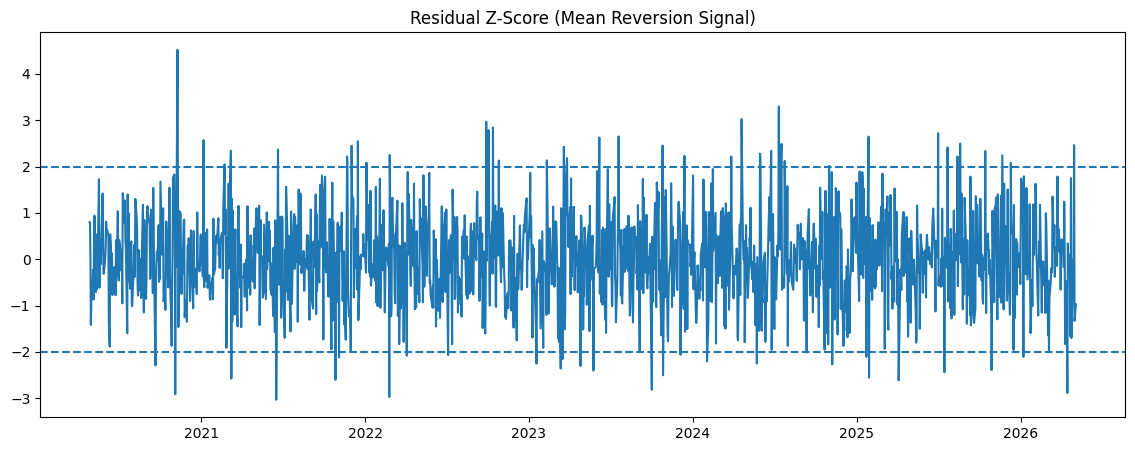

In [120]:
# ----------------------------
# 6. Example signal: z-score
# ----------------------------
zscore = (residuals - residuals.rolling(60).mean()) / residuals.rolling(60).std()

plt.figure(figsize=(14, 5))
plt.plot(zscore)
plt.title("Residual Z-Score (Mean Reversion Signal)")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.show()

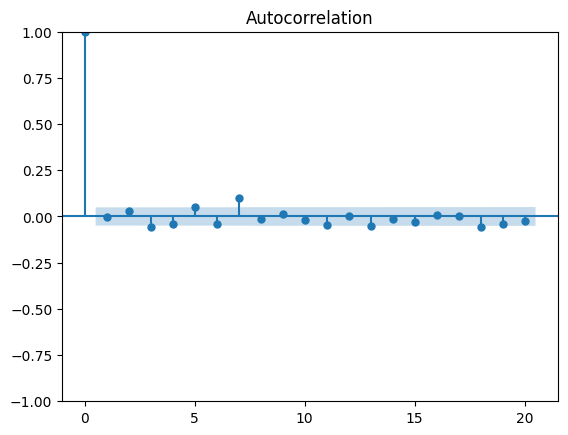

In [121]:
plot_acf(residuals, lags=20)
plt.show()

In [122]:
model.params

const   -0.000832
MKT      0.630373
MOM      0.544942
VOL      0.057676
dtype: float64

In [123]:
resid_lag = residuals.shift(1).dropna()
resid_curr = residuals.loc[resid_lag.index]

X = sm.add_constant(resid_lag)
model = sm.OLS(resid_curr, X).fit()


phi = model.params[0]
half_life = -np.log(2) / np.log(abs(phi))

print("phi:", phi)
print("half-life:", half_life)

phi: -0.0029894716212619217
half-life: 0.11924787357677552


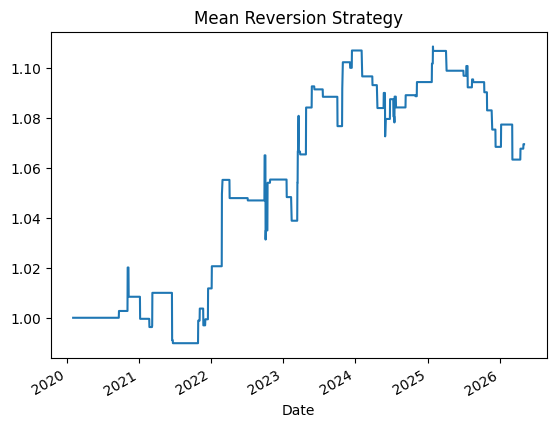

Sharpe: 0.33775462624818947


In [124]:
signal = zscore.copy()

positions = pd.Series(0, index=signal.index)
positions[signal < -2] = 1  # long
positions[signal > 2] = -1  # short
positions = positions.shift(1)  # avoid lookahead

pnl = positions * returns["TSLA"]
cum_pnl = (1 + pnl).cumprod()
cum_pnl.plot(title="Mean Reversion Strategy")

plt.show()

print("Sharpe:", pnl.mean() / pnl.std() * np.sqrt(252))